# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)
print('Everything is imported boss')

Everything is imported boss


# **Data Exploration**

## **Load the data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 5540 Rows and 9 columns with 40 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5540 entries, 0 to 5539
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5428 non-null   float64
 1   account_balance    5430 non-null   float64
 2   call_duration_sec  5430 non-null   float64
 3   campaign_contacts  5429 non-null   float64
 4   prev_contacts      5430 non-null   float64
 5   has_loan           5428 non-null   float64
 6   has_housing        5430 non-null   float64
 7   credit_score       5430 non-null   str    
 8   subscribed         5540 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 416.9 KB


In [6]:
df.sample(10)

,age,account_balance,call_duration_sec,campaign_contacts,prev_contacts,has_loan,has_housing,credit_score,subscribed
847,67.0,1648.28,352.0,6.0,2.0,1.0,1.0,585.0,1
678,41.0,10608.64,314.0,3.0,2.0,1.0,1.0,352.0,1
5264,52.0,19470.38,289.0,7.0,0.0,0.0,NaN,477.0,0
2353,39.0,46009.39,451.0,2.0,2.0,0.0,0.0,604.0,1
3357,54.0,7605.54,264.0,14.0,0.0,0.0,0.0,444.0,1
4482,32.0,7614.96,152.0,3.0,2.0,1.0,0.0,847.0,0
2555,37.0,26771.33,336.0,14.0,2.0,0.0,1.0,371.0,0
186,55.0,18081.77,520.0,4.0,2.0,0.0,1.0,716.0,1
499,57.0,27364.92,356.0,1.0,2.0,1.0,0.0,524.0,1
5313,26.0,NaN,401.0,12.0,0.0,0.0,0.0,782.0_err,1


In [7]:
df.describe()

,age,account_balance,call_duration_sec,campaign_contacts,prev_contacts,has_loan,has_housing,subscribed
count,5428.000000,5430.000000,5430.000000,5429.000000,5430.000000,5428.000000,5430.000000,5540.000000
mean,43.131724,24778.190436,303.220074,7.542273,2.018969,0.299558,0.509945,0.497112
std,14.950165,14453.528371,172.252093,4.277875,1.414803,0.458107,0.499947,0.500037
min,-5.000000,-10000.000000,-30.000000,1.000000,-2.000000,0.000000,0.000000,0.000000
25%,30.000000,12176.830000,155.000000,4.000000,1.000000,0.000000,0.000000,0.000000
50%,43.000000,24564.305000,304.000000,8.000000,2.000000,0.000000,1.000000,0.000000
75%,56.000000,37279.247500,453.000000,11.000000,3.000000,1.000000,1.000000,1.000000
max,69.000000,49997.290000,599.000000,100.000000,4.000000,1.000000,1.000000,1.000000


In [8]:
df.isna().sum()

age                  112
account_balance      110
call_duration_sec    110
campaign_contacts    111
prev_contacts        110
has_loan             112
has_housing          110
credit_score         110
subscribed             0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [9]:
df_copy = df.copy()
print('Copy created')

Copy created


## **DataType**

In [11]:
df_copy['credit_score'] = df_copy['credit_score'].replace('_err','',regex=True).astype('float')

In [ ]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan
    
df_copy.loc[df_copy['age']>100,'age'] = np.nan
df_copy.loc[df_copy['age']<18,'age'] = np.nan

## **Outliers**

In [15]:
Columns = df_copy.columns.tolist()
Columns.remove('subscribed')
Columns.remove('has_housing')
Columns.remove('has_loan')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [17]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 40
After: 0


## **NaN Values**

In [19]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('subscribed')
Round.remove('age')
Round.remove('has_loan')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['age','has_loan']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
age                  111
account_balance      111
call_duration_sec    111
campaign_contacts    112
prev_contacts        111
has_loan             110
has_housing          110
credit_score         111
subscribed             0
dtype: int64
NaN values in the Dataset After Cleaning is: 
age                  0
account_balance      0
call_duration_sec    0
campaign_contacts    0
prev_contacts        0
has_loan             0
has_housing          0
credit_score         0
subscribed           0
dtype: int64


# **Data Preperation**

In [20]:
features = df_copy.columns.tolist()
features.remove('subscribed')
X = df_copy[features]
y = df_copy['subscribed']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (5500, 8)
y Shape: (5500,)


In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (4400, 8)
X_test Shape:  (1100, 8)
y_train Shape: (4400,)
y_test Shape:  (1100,)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Suggested starting K: {int(math.sqrt(len(X_train)))}")

Suggested starting K: 66


# **Model**

## **Optimal K**

In [23]:
train_scores = []
test_scores  = []
k_range      = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(test_scores)]
print(f"Optimal K: {best_k}")

Optimal K: 29


## **Train**

In [24]:
model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',   # distance metric
    weights='uniform'     # all neighbors vote equally
)

model.fit(X_train_scaled, y_train)
print(f"Model trained with K={best_k} ✅")

Model trained with K=29 ✅


## **Evaluation & Pridict**

In [25]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.80      0.84      0.82       537
         1.0       0.84      0.80      0.82       563

    accuracy                           0.82      1100
   macro avg       0.82      0.82      0.82      1100
weighted avg       0.82      0.82      0.82      1100

Accuracy: 0.8200


## **OverFitting Check**

In [26]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8323
Testing Accuracy:  0.8200
Gap:               0.0123


## **Charts**

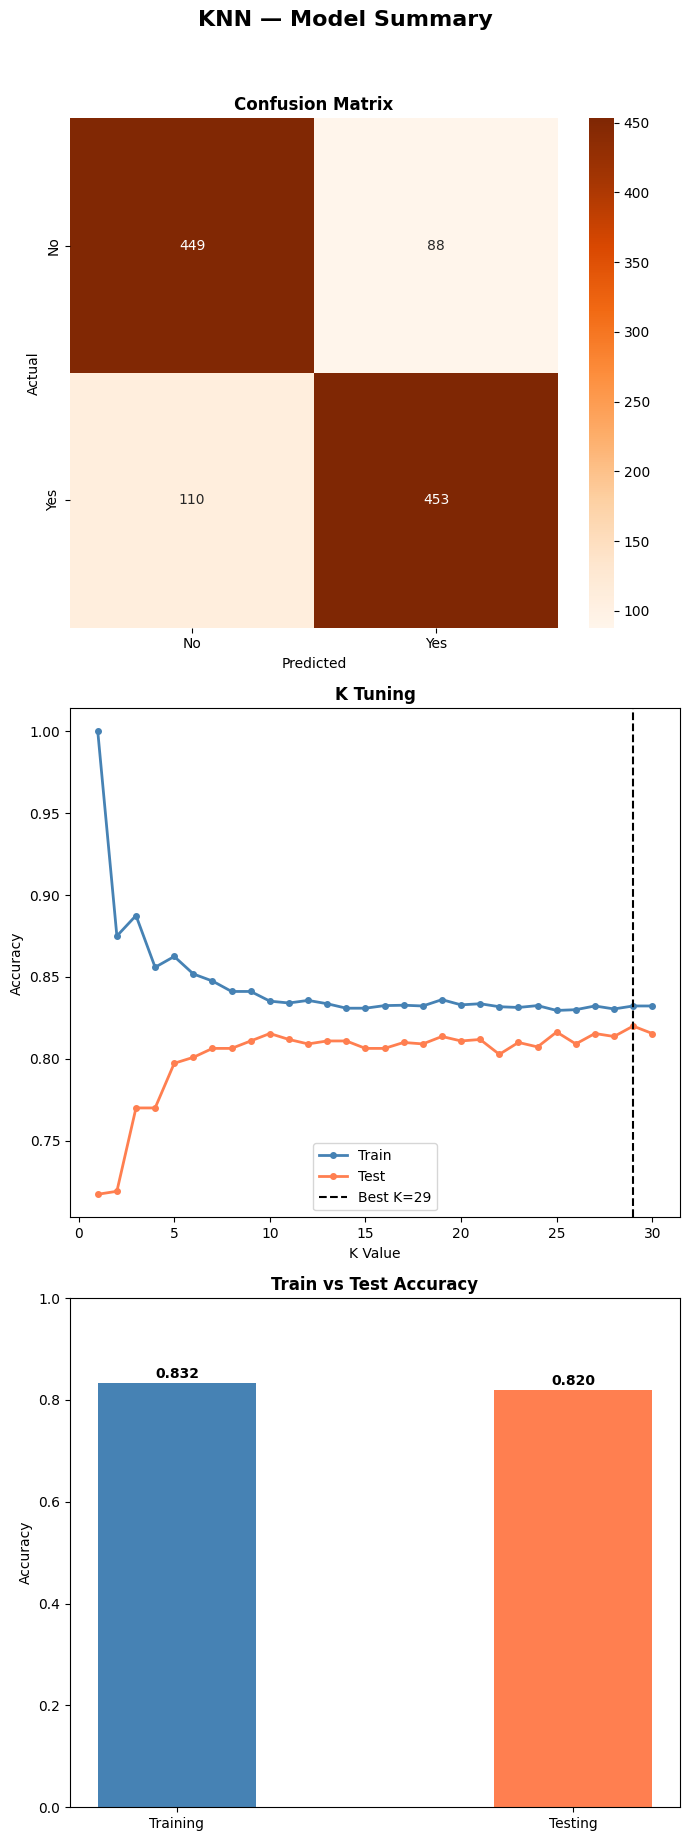

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — K Tuning
axes[1].plot(k_range, train_scores, marker='o', markersize=4,
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(k_range, test_scores,  marker='o', markersize=4,
             label='Test',  color='coral',     linewidth=2)
axes[1].axvline(best_k, linestyle='--', color='black',
                label=f'Best K={best_k}')
axes[1].set_title('K Tuning', fontweight='bold')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('KNN — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()